In [30]:
import pandas as pd
import joblib

In [31]:
df = joblib.load(
    r'C:\Users\divya\Desktop\Team parakh\Parakh-task-5\cleaned_dataset.pkl')
df.head()

,experience_years,python,java,c_cpp,javascript,typescript,html_css,react,angular_vue,nodejs,...,total_skills,ml_skill_count,web_skill_count,experience_skill_score,education_level_B.Tech / B.E.,education_level_BCA,education_level_M.Tech / MCA,education_level_Self-Taught,programming_score,data_skill_score
0,0,0,0,0,1,1,1,1,0,1,...,9,0,6,0,0.0,0.0,0.0,0.0,2,1
1,2,0,0,0,1,1,1,0,1,1,...,6,0,5,12,0.0,0.0,0.0,0.0,2,0
2,3,1,0,0,0,0,0,0,0,0,...,7,1,0,21,1.0,0.0,0.0,0.0,1,1
5,3,0,0,0,1,0,1,1,0,0,...,5,1,3,15,0.0,1.0,0.0,0.0,1,0
6,1,1,0,0,0,0,0,0,0,0,...,6,3,0,6,0.0,0.0,0.0,0.0,1,3


In [32]:
print(df.columns.tolist())

['experience_years', 'python', 'java', 'c_cpp', 'javascript', 'typescript', 'html_css', 'react', 'angular_vue', 'nodejs', 'fastapi_flask', 'django', 'sql', 'nosql', 'mongodb', 'postgresql', 'pandas_numpy', 'scikit_learn', 'deep_learning', 'pytorch_tensorflow', 'nlp', 'computer_vision', 'docker', 'kubernetes', 'git', 'linux', 'aws', 'azure_gcp', 'ci_cd', 'terraform', 'cybersecurity_basics', 'penetration_testing', 'flutter_react_native', 'target_career', 'total_skills', 'ml_skill_count', 'web_skill_count', 'experience_skill_score', 'education_level_B.Tech / B.E.', 'education_level_BCA', 'education_level_M.Tech / MCA', 'education_level_Self-Taught', 'programming_score', 'data_skill_score']


In [33]:
print(df.shape)

(1399, 44)


In [34]:
print(df.dtypes)

experience_years                   int64
python                             int64
java                               int64
c_cpp                              int64
javascript                         int64
typescript                         int64
html_css                           int64
react                              int64
angular_vue                        int64
nodejs                             int64
fastapi_flask                      int64
django                             int64
sql                                int64
nosql                              int64
mongodb                            int64
postgresql                         int64
pandas_numpy                       int64
scikit_learn                       int64
deep_learning                      int64
pytorch_tensorflow                 int64
nlp                                int64
computer_vision                    int64
docker                             int64
kubernetes                         int64
git             

In [35]:
career_skills = {
    "Data Scientist": [
        "Python",
        "SQL",
        "Statistics",
        "Machine Learning",
        "Pandas",
        "NumPy"
    ],

    "ML Engineer": [
        "Python",
        "Machine Learning",
        "Statistics",
        "SQL",
        "Deep Learning",
        "Model Deployment"
    ],

    "Data Analyst": [
        "Python",
        "SQL",
        "Statistics",
        "Excel",
        "Pandas",
        "Data Visualization"
    ],

    "Software Developer": [
        "Python",
        "Programming",
        "Data Structures",
        "Algorithms",
        "Git"
    ],

    "Web Developer": [
        "HTML",
        "CSS",
        "JavaScript",
        "React",
        "Git"
    ]
}

In [36]:
student_skills = [
    "Python",
    "SQL",
    "Machine Learning",
    "Pandas"
]

In [37]:
print(student_skills)

['Python', 'SQL', 'Machine Learning', 'Pandas']


In [38]:
target_career = "ML Engineer"
required_skills = career_skills[target_career]
missing_skills = [
    skill for skill in required_skills
    if skill not in student_skills
]
available_skills = [
    skill for skill in required_skills
    if skill in student_skills
]
print("Career:", target_career)
print("\nSkills You Have:")
print(available_skills)
print("\nMissing Skills:")
print(missing_skills)

Career: ML Engineer

Skills You Have:
['Python', 'Machine Learning', 'SQL']

Missing Skills:
['Statistics', 'Deep Learning', 'Model Deployment']


In [39]:
match_score = (
    len(available_skills) /len(required_skills)) * 100
print("Career:", target_career)
print("Match Score:", round(match_score, 2), "%")

Career: ML Engineer
Match Score: 50.0 %


In [40]:
def skill_gap_analysis(student_skills, target_career):
    required_skills = career_skills[target_career]
    available_skills = [
        skill for skill in required_skills
        if skill in student_skills]
    missing_skills = [
        skill for skill in required_skills
        if skill not in student_skills]
        
    match_score = (
        len(available_skills) /
        len(required_skills)
    ) * 100

    return {
        "career": target_career,
        "available_skills": available_skills,
        "missing_skills": missing_skills,
        "match_score": round(match_score, 2)
    }

In [41]:
result = skill_gap_analysis(
    student_skills,
    "ML Engineer"
)

print(result)

{'career': 'ML Engineer', 'available_skills': ['Python', 'Machine Learning', 'SQL'], 'missing_skills': ['Statistics', 'Deep Learning', 'Model Deployment'], 'match_score': 50.0}


In [42]:
print("Career:", result["career"])
print("Match Score:", result["match_score"], "%")

print("\nAvailable Skills:")
for skill in result["available_skills"]:
    print("✓", skill)

print("\nMissing Skills:")
for skill in result["missing_skills"]:
    print("✗", skill)

Career: ML Engineer
Match Score: 50.0 %

Available Skills:
✓ Python
✓ Machine Learning
✓ SQL

Missing Skills:
✗ Statistics
✗ Deep Learning
✗ Model Deployment


In [43]:
career_results = []

for career in career_skills:
    result = skill_gap_analysis(
        student_skills,
        career
    )
    career_results.append(result)

In [44]:
career_results = []
for career in career_skills:
    result = skill_gap_analysis(student_skills,career)
    career_results.append(result)

In [45]:
career_results_df = pd.DataFrame(career_results)
career_results_df

,career,available_skills,missing_skills,match_score
0,Data Scientist,"[Python, SQL, Machine Learning, Pandas]","[Statistics, NumPy]",66.67
1,ML Engineer,"[Python, Machine Learning, SQL]","[Statistics, Deep Learning, Model Deployment]",50.00
2,Data Analyst,"[Python, SQL, Pandas]","[Statistics, Excel, Data Visualization]",50.00
3,Software Developer,[Python],"[Programming, Data Structures, Algorithms, Git]",20.00
4,Web Developer,[],"[HTML, CSS, JavaScript, React, Git]",0.00


In [46]:
career_results_df = career_results_df.sort_values(by="match_score",ascending=False)
career_results_df

,career,available_skills,missing_skills,match_score
0,Data Scientist,"[Python, SQL, Machine Learning, Pandas]","[Statistics, NumPy]",66.67
1,ML Engineer,"[Python, Machine Learning, SQL]","[Statistics, Deep Learning, Model Deployment]",50.00
2,Data Analyst,"[Python, SQL, Pandas]","[Statistics, Excel, Data Visualization]",50.00
3,Software Developer,[Python],"[Programming, Data Structures, Algorithms, Git]",20.00
4,Web Developer,[],"[HTML, CSS, JavaScript, React, Git]",0.00


In [47]:
top_careers = career_results_df.head(3)
top_careers

,career,available_skills,missing_skills,match_score
0,Data Scientist,"[Python, SQL, Machine Learning, Pandas]","[Statistics, NumPy]",66.67
1,ML Engineer,"[Python, Machine Learning, SQL]","[Statistics, Deep Learning, Model Deployment]",50.00
2,Data Analyst,"[Python, SQL, Pandas]","[Statistics, Excel, Data Visualization]",50.00


In [48]:
print("Recommended Careers\n")
for i, row in top_careers.iterrows():
    print(
        row["career"],
        "->",
        row["match_score"],
        "%"
    )

Recommended Careers

Data Scientist -> 66.67 %
ML Engineer -> 50.0 %
Data Analyst -> 50.0 %


In [49]:
top_career = career_results_df.iloc[0]
print("Recommended Career:")
print(top_career["career"])
print("\nMatch Score:")
print(top_career["match_score"], "%")
print("\nMissing Skills:")

for skill in top_career["missing_skills"]:
    print("•", skill)

Recommended Career:
Data Scientist

Match Score:
66.67 %

Missing Skills:
• Statistics
• NumPy


In [50]:
def career_recommendation(student_skills):
    results = []
    for career in career_skills:
        required_skills = career_skills[career]
        available_skills = [
            skill for skill in required_skills
            if skill in student_skills
        ]
        missing_skills = [
            skill for skill in required_skills
            if skill not in student_skills
        ]
        match_score = (
            len(available_skills) / len(required_skills)) * 100

        results.append({
            "career": career,
            "match_score": round(match_score, 2),
            "available_skills": available_skills,
            "missing_skills": missing_skills
        })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(
        by="match_score",
        ascending=False).reset_index(drop=True)
    return results_df

In [51]:
recommendations = career_recommendation(student_skills)
recommendations

,career,match_score,available_skills,missing_skills
0,Data Scientist,66.67,"[Python, SQL, Machine Learning, Pandas]","[Statistics, NumPy]"
1,ML Engineer,50.00,"[Python, Machine Learning, SQL]","[Statistics, Deep Learning, Model Deployment]"
2,Data Analyst,50.00,"[Python, SQL, Pandas]","[Statistics, Excel, Data Visualization]"
3,Software Developer,20.00,[Python],"[Programming, Data Structures, Algorithms, Git]"
4,Web Developer,0.00,[],"[HTML, CSS, JavaScript, React, Git]"


In [52]:
top_3_careers = recommendations.head(3)
top_3_careers

,career,match_score,available_skills,missing_skills
0,Data Scientist,66.67,"[Python, SQL, Machine Learning, Pandas]","[Statistics, NumPy]"
1,ML Engineer,50.00,"[Python, Machine Learning, SQL]","[Statistics, Deep Learning, Model Deployment]"
2,Data Analyst,50.00,"[Python, SQL, Pandas]","[Statistics, Excel, Data Visualization]"


In [53]:
for i, row in top_3_careers.iterrows():
    print(
        f"{i + 1}. {row['career']} "
        f"-> {row['match_score']}%"
    )

1. Data Scientist -> 66.67%
2. ML Engineer -> 50.0%
3. Data Analyst -> 50.0%


In [54]:
for i, row in top_3_careers.iterrows():
    print("Career:", row["career"])
    print("Match Score:", row["match_score"], "%")

    print("\nSkills You Have:")
    for skill in row["available_skills"]:
        print("✓", skill)

    print("\nSkills You Need:")
    for skill in row["missing_skills"]:
        print("✗", skill)

Career: Data Scientist
Match Score: 66.67 %

Skills You Have:
✓ Python
✓ SQL
✓ Machine Learning
✓ Pandas

Skills You Need:
✗ Statistics
✗ NumPy
Career: ML Engineer
Match Score: 50.0 %

Skills You Have:
✓ Python
✓ Machine Learning
✓ SQL

Skills You Need:
✗ Statistics
✗ Deep Learning
✗ Model Deployment
Career: Data Analyst
Match Score: 50.0 %

Skills You Have:
✓ Python
✓ SQL
✓ Pandas

Skills You Need:
✗ Statistics
✗ Excel
✗ Data Visualization


In [55]:
top_career = recommendations.iloc[0]
recommended_skills = top_career["missing_skills"]
print("Recommended Career:")
print(top_career["career"])
print("\nSkills Recommended to Learn:")

for skill in recommended_skills:
    print("→", skill)

Recommended Career:
Data Scientist

Skills Recommended to Learn:
→ Statistics
→ NumPy


In [56]:
final_recommendation = {
    "recommended_career": recommendations.iloc[0]["career"],
    "match_score": recommendations.iloc[0]["match_score"],
    "skills_to_learn": recommendations.iloc[0]["missing_skills"],
    "top_careers": recommendations.head(3)["career"].tolist()
}
final_recommendation

{'recommended_career': 'Data Scientist',
 'match_score': np.float64(66.67),
 'skills_to_learn': ['Statistics', 'NumPy'],
 'top_careers': ['Data Scientist', 'ML Engineer', 'Data Analyst']}

In [57]:
 import json
 with open(
     r'C:\Users\divya\Desktop\Team parakh\career_skill_mapping.json',
     'w'
 ) as file:
    json.dump(final_recommendation,file,indent=4)

In [58]:
#  recommendations.to_csv(
#      r'C:\Users\Gauri\Parakh-task-5\career_recommendations.csv',
#    index=False)

In [59]:
import matplotlib.pyplot as plt

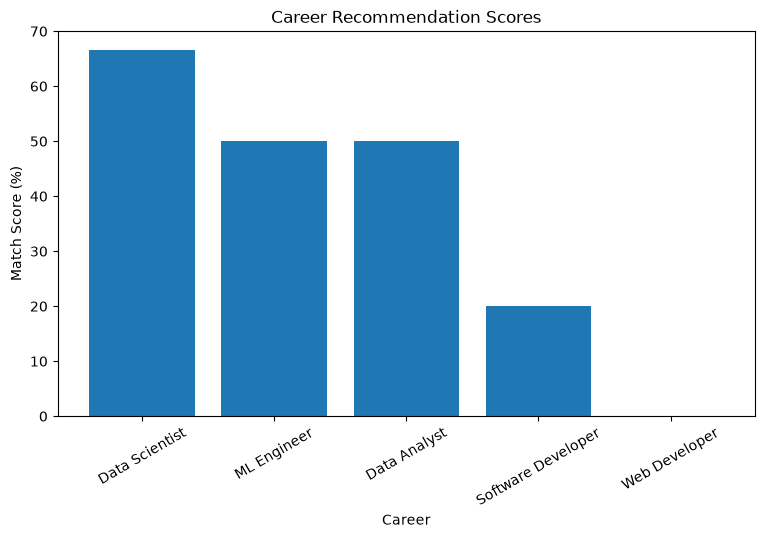

In [60]:
plt.figure(figsize=(9, 5))
plt.bar(
    recommendations["career"],
    recommendations["match_score"])
plt.xlabel("Career")
plt.ylabel("Match Score (%)")
plt.title("Career Recommendation Scores")
plt.xticks(rotation=30)
plt.show()

In [61]:
print("Career Recommendation")
print("Career:", top_career["career"])
print("Match Score:", top_career["match_score"], "%")
print("Skills to Learn:")

for skill in top_career["missing_skills"]:
    print("-", skill)
print("\nTop 3 Careers:")

for i, career in enumerate(top_careers["career"], 1):
    print(i, career)

Career Recommendation
Career: Data Scientist
Match Score: 66.67 %
Skills to Learn:
- Statistics
- NumPy

Top 3 Careers:
1 Data Scientist
2 ML Engineer
3 Data Analyst


In [62]:
import json
data = {
    "career": top_career["career"],
    "match_score": top_career["match_score"],
    "skills_to_learn": top_career["missing_skills"]}

with open("recommendation.json", "w") as file:
    json.dump(data, file, indent=4)
print("Saved successfully")

Saved successfully


In [63]:
recommendations.to_csv(
    "career_recommendations.csv",
    index=False)
print("Saved successfully")

Saved successfully


In [64]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [65]:
final_model = lr
print("Final Model: Logistic Regression")

Final Model: Logistic Regression


In [66]:
import joblib
pca = joblib.load("../pca.pkl")

In [67]:
scaler = joblib.load("../standard_scaler.pkl")

In [68]:
final_model = joblib.load("../final_model.pkl")


In [69]:
kmeans = joblib.load("../kmeans_model.pkl")

In [70]:
import joblib
import pandas as pd

df = joblib.load("../cleaned_dataset.pkl")
print(df.shape)
print(df.head())

(1399, 44)
   experience_years  python  java  c_cpp  javascript  typescript  html_css  \
0                 0       0     0      0           1           1         1   
1                 2       0     0      0           1           1         1   
2                 3       1     0      0           0           0         0   
5                 3       0     0      0           1           0         1   
6                 1       1     0      0           0           0         0   

   react  angular_vue  nodejs  ...  total_skills  ml_skill_count  \
0      1            0       1  ...             9               0   
1      0            1       1  ...             6               0   
2      0            0       0  ...             7               1   
5      1            0       0  ...             5               1   
6      0            0       0  ...             6               3   

   web_skill_count  experience_skill_score  education_level_B.Tech / B.E.  \
0                6                

In [71]:
x = df.drop("target_career", axis=1)
print("Features:", x.shape)

Features: (1399, 43)


In [72]:
sample = x.iloc[:1]
print(sample)

   experience_years  python  java  c_cpp  javascript  typescript  html_css  \
0                 0       0     0      0           1           1         1   

   react  angular_vue  nodejs  ...  total_skills  ml_skill_count  \
0      1            0       1  ...             9               0   

   web_skill_count  experience_skill_score  education_level_B.Tech / B.E.  \
0                6                       0                            0.0   

   education_level_BCA  education_level_M.Tech / MCA  \
0                  0.0                           0.0   

   education_level_Self-Taught  programming_score  data_skill_score  
0                          0.0                  2                 1  

[1 rows x 43 columns]


In [73]:
sample_scaled = scaler.transform(sample)
print(sample_scaled.shape)

(1, 43)


In [74]:
sample_pca = pca.transform(sample_scaled)
print(sample_pca.shape)

(1, 32)


In [75]:
predicted_career = final_model.predict(sample_pca)[0]
print("Predicted Career:", predicted_career)

Predicted Career: Frontend Developer


In [76]:
predicted_cluster = kmeans.predict(sample_scaled)[0]
print("Student Cluster:", predicted_cluster)

Student Cluster: 0


In [77]:
print("Career:", predicted_career)
print("Cluster:", predicted_cluster)

Career: Frontend Developer
Cluster: 0


In [78]:
print(predicted_career in career_skills)

False


In [79]:
print("Predicted career:", predicted_career)

Predicted career: Frontend Developer


In [80]:
print("Career names in mapping:")
print(list(career_skills.keys()))

Career names in mapping:
['Data Scientist', 'ML Engineer', 'Data Analyst', 'Software Developer', 'Web Developer']


In [81]:
career_skills["Frontend Developer"] = [
    "HTML",
    "CSS",
    "JavaScript",
    "React",
    "Git"
]

In [82]:
print(predicted_career in career_skills)

True


In [83]:
required_skills = career_skills[predicted_career]
print("Career:", predicted_career)
print("Required Skills:", required_skills)

Career: Frontend Developer
Required Skills: ['HTML', 'CSS', 'JavaScript', 'React', 'Git']


In [84]:
missing_skills = [
    skill for skill in required_skills
    if skill not in student_skills
]
print("Skills to Learn:", missing_skills)

Skills to Learn: ['HTML', 'CSS', 'JavaScript', 'React', 'Git']


In [85]:
print("Recommended Career:", predicted_career)
print("Cluster:", predicted_cluster)
print("Skills to Learn:", missing_skills)

Recommended Career: Frontend Developer
Cluster: 0
Skills to Learn: ['HTML', 'CSS', 'JavaScript', 'React', 'Git']


In [86]:
print(df["target_career"].unique())

['Frontend Developer' 'Cloud Architect' 'Data Analyst'
 'Mobile App Developer' 'Machine Learning Engineer' 'AI Engineer'
 'DevOps Engineer' 'Full Stack Developer' 'Cybersecurity Analyst'
 'Database Administrator' 'Backend Developer' 'Data Scientist']


In [87]:
career_skills = {
    "Frontend Developer": [
        "HTML", "CSS", "JavaScript", "React", "Git"
    ],

    "Cloud Architect": [
        "Python", "Cloud Computing", "AWS", "Azure", "Networking"
    ],

    "Data Analyst": [
        "Python", "SQL", "Excel", "Pandas", "Data Visualization"
    ],

    "Mobile App Developer": [
        "Java", "Kotlin", "Android", "Flutter", "Git"
    ],

    "Machine Learning Engineer": [
        "Python", "Machine Learning", "Pandas", "NumPy", "Scikit-learn"
    ],

    "AI Engineer": [
        "Python", "Machine Learning", "Deep Learning", "TensorFlow", "NLP"
    ],

    "DevOps Engineer": [
        "Linux", "Git", "Docker", "Kubernetes", "CI/CD"
    ],

    "Full Stack Developer": [
        "HTML", "CSS", "JavaScript", "React", "Node.js", "SQL", "Git"
    ],

    "Cybersecurity Analyst": [
        "Networking", "Linux", "Cybersecurity", "Python", "Ethical Hacking"
    ],

    "Database Administrator": [
        "SQL", "MySQL", "Database Management", "Linux", "Backup and Recovery"
    ],

    "Backend Developer": [
        "Python", "SQL", "APIs", "Django", "Git"
    ],

    "Data Scientist": [
        "Python", "SQL", "Machine Learning", "Pandas", "Statistics"
    ]
}

In [88]:
print(df["target_career"].isin(career_skills.keys()).all())

True


In [89]:
print(df["target_career"].isin(career_skills.keys()).all())

True


In [90]:
print("Predicted Career:", predicted_career)
print("Required Skills:", career_skills[predicted_career])

Predicted Career: Frontend Developer
Required Skills: ['HTML', 'CSS', 'JavaScript', 'React', 'Git']


In [91]:
student_skills = [
    "Python",
    "SQL",
    "Machine Learning",
    "Pandas"
]

In [92]:
required_skills = career_skills[predicted_career]
missing_skills = [
    skill for skill in required_skills
    if skill not in student_skills
]
print("Skills to Learn:", missing_skills)

Skills to Learn: ['HTML', 'CSS', 'JavaScript', 'React', 'Git']


In [93]:
print("Career:", predicted_career)
print("Cluster:", predicted_cluster)
print("Skills to Learn:", missing_skills)

Career: Frontend Developer
Cluster: 0
Skills to Learn: ['HTML', 'CSS', 'JavaScript', 'React', 'Git']


In [95]:
available_skills = [
    skill for skill in required_skills
    if skill in student_skills
]
print("Skills You Have:", available_skills)

Skills You Have: []


In [96]:
match_score = (
    len(available_skills) / len(required_skills)) * 100
print("Match Score:", round(match_score, 2), "%")

Match Score: 0.0 %


In [97]:
student_skills = [
    "HTML",
    "CSS",
    "JavaScript",
    "Git"
]

In [98]:
required_skills = career_skills[predicted_career]
print("Required Skills:", required_skills)

Required Skills: ['HTML', 'CSS', 'JavaScript', 'React', 'Git']


In [99]:
available_skills = [
    skill for skill in required_skills
    if skill in student_skills
]
print("Skills You Have:", available_skills)

Skills You Have: ['HTML', 'CSS', 'JavaScript', 'Git']


In [101]:
missing_skills = [
    skill for skill in required_skills
    if skill not in student_skills
]
print("Skills to Learn:", missing_skills)

Skills to Learn: ['React']


In [102]:
match_score = (
    len(available_skills) / len(required_skills)) * 100
print("Match Score:", round(match_score, 2), "%")

Match Score: 80.0 %


In [103]:
recommendation = {
    "career": predicted_career,
    "cluster": int(predicted_cluster),
    "match_score": round(match_score, 2),
    "skills_you_have": available_skills,
    "skills_to_learn": missing_skills
}

print(recommendation)

{'career': 'Frontend Developer', 'cluster': 0, 'match_score': 80.0, 'skills_you_have': ['HTML', 'CSS', 'JavaScript', 'Git'], 'skills_to_learn': ['React']}


In [104]:
print("Career:", predicted_career)
print("Cluster:", predicted_cluster)
print("Match Score:", round(match_score, 2), "%")
print("Skills You Have:", available_skills)
print("Skills to Learn:", missing_skills)

Career: Frontend Developer
Cluster: 0
Match Score: 80.0 %
Skills You Have: ['HTML', 'CSS', 'JavaScript', 'Git']
Skills to Learn: ['React']


In [105]:
import json

with open("recommendation.json", "w") as file:
    json.dump(recommendation, file, indent=4)
print("Recommendation saved successfully")

Recommendation saved successfully


In [106]:
import pandas as pd

final_recommendation = pd.DataFrame([{
    "Career": predicted_career,
    "Cluster": predicted_cluster,
    "Match Score": round(match_score, 2),
    "Skills You Have": ", ".join(available_skills),
    "Skills to Learn": ", ".join(missing_skills)
}])

final_recommendation

,Career,Cluster,Match Score,Skills You Have,Skills to Learn
0,Frontend Developer,0,80.0,"HTML, CSS, JavaScript, Git",React


In [109]:
final_recommendation.to_csv("final_recommendation.csv",index=False)

In [110]:
import json
with open("recommendation.json", "w") as file:
    json.dump(recommendation, file, indent=4)


In [ ]:
def get_recommendation(student_skills):
    required_skills = career_skills[predicted_career]
    available_skills = [
        skill for skill in required_skills
        if skill in student_skills
    ]

    missing_skills = [
        skill for skill in required_skills
        if skill not in student_skills
    ]
    match_score = (
        len(available_skills) / len(required_skills)) * 100

    return {
        "career": predicted_career,
        "cluster": int(predicted_cluster),
        "match_score": round(match_score, 2),
        "skills_you_have": available_skills,
        "skills_to_learn": missing_skills
    }

In [112]:
result = get_recommendation(student_skills)
print(result)

{'career': 'Frontend Developer', 'cluster': 0, 'match_score': 80.0, 'skills_you_have': ['HTML', 'CSS', 'JavaScript', 'Git'], 'skills_to_learn': ['React']}


In [113]:
print("Career:", result["career"])
print("Cluster:", result["cluster"])
print("Match Score:", result["match_score"], "%")
print("Skills You Have:", result["skills_you_have"])
print("Skills to Learn:", result["skills_to_learn"])

Career: Frontend Developer
Cluster: 0
Match Score: 80.0 %
Skills You Have: ['HTML', 'CSS', 'JavaScript', 'Git']
Skills to Learn: ['React']


In [114]:
print(x.columns.tolist())

['experience_years', 'python', 'java', 'c_cpp', 'javascript', 'typescript', 'html_css', 'react', 'angular_vue', 'nodejs', 'fastapi_flask', 'django', 'sql', 'nosql', 'mongodb', 'postgresql', 'pandas_numpy', 'scikit_learn', 'deep_learning', 'pytorch_tensorflow', 'nlp', 'computer_vision', 'docker', 'kubernetes', 'git', 'linux', 'aws', 'azure_gcp', 'ci_cd', 'terraform', 'cybersecurity_basics', 'penetration_testing', 'flutter_react_native', 'total_skills', 'ml_skill_count', 'web_skill_count', 'experience_skill_score', 'education_level_B.Tech / B.E.', 'education_level_BCA', 'education_level_M.Tech / MCA', 'education_level_Self-Taught', 'programming_score', 'data_skill_score']


In [115]:
print(x.shape)

(1399, 43)


In [116]:
for i, col in enumerate(x.columns, 1):
    print(i, col)

1 experience_years
2 python
3 java
4 c_cpp
5 javascript
6 typescript
7 html_css
8 react
9 angular_vue
10 nodejs
11 fastapi_flask
12 django
13 sql
14 nosql
15 mongodb
16 postgresql
17 pandas_numpy
18 scikit_learn
19 deep_learning
20 pytorch_tensorflow
21 nlp
22 computer_vision
23 docker
24 kubernetes
25 git
26 linux
27 aws
28 azure_gcp
29 ci_cd
30 terraform
31 cybersecurity_basics
32 penetration_testing
33 flutter_react_native
34 total_skills
35 ml_skill_count
36 web_skill_count
37 experience_skill_score
38 education_level_B.Tech / B.E.
39 education_level_BCA
40 education_level_M.Tech / MCA
41 education_level_Self-Taught
42 programming_score
43 data_skill_score


In [117]:
print(x.dtypes)

experience_years                   int64
python                             int64
java                               int64
c_cpp                              int64
javascript                         int64
typescript                         int64
html_css                           int64
react                              int64
angular_vue                        int64
nodejs                             int64
fastapi_flask                      int64
django                             int64
sql                                int64
nosql                              int64
mongodb                            int64
postgresql                         int64
pandas_numpy                       int64
scikit_learn                       int64
deep_learning                      int64
pytorch_tensorflow                 int64
nlp                                int64
computer_vision                    int64
docker                             int64
kubernetes                         int64
git             

In [122]:
import json
feature_names = x.columns.tolist()
with open("../feature_names.json", "w") as file:
    json.dump(feature_names, file, indent=4)

print("Feature names saved")
print("Total features:", len(feature_names))

Feature names saved
Total features: 43


In [123]:
print("Number of input features:", len(feature_names))
print("PCA components:", pca.n_components_)
print("Final model:", type(final_model).__name__)

Number of input features: 43
PCA components: 32
Final model: RandomForestClassifier


In [124]:
def predict_student(student_data):
    student_data = student_data[feature_names]
    scaled_data = scaler.transform(student_data)
    pca_data = pca.transform(scaled_data)
    career = final_model.predict(pca_data)[0]
    cluster = kmeans.predict(scaled_data)[0]
    return career, cluster

In [125]:
sample_student = x.iloc[[0]]
career, cluster = predict_student(sample_student)
print("Career:", career)
print("Cluster:", cluster)

Career: Frontend Developer
Cluster: 0


In [127]:
sample_student = x.iloc[[10]]
career, cluster = predict_student(sample_student)
print("Career:", career)
print("Cluster:", cluster)

Career: Machine Learning Engineer
Cluster: 1


In [128]:
import joblib
saved_model = joblib.load("../final_model.pkl")
print("Saved model:", type(saved_model).__name__)

Saved model: RandomForestClassifier


In [130]:
final_model = joblib.load("../final_model.pkl")
print("Final model:", type(final_model).__name__)

Final model: RandomForestClassifier


In [132]:
scaler = joblib.load("../standard_scaler.pkl")
print("Scaler:", type(scaler).__name__)

Scaler: StandardScaler


In [133]:
pca = joblib.load("../pca.pkl")
print("PCA:", type(pca).__name__)
print("Components:", pca.n_components_)

PCA: PCA
Components: 32


In [134]:
kmeans = joblib.load("../kmeans_model.pkl")
print("K-Means:", type(kmeans).__name__)

K-Means: KMeans


In [135]:
final_model = joblib.load("../final_model.pkl")
scaler = joblib.load("../standard_scaler.pkl")
pca = joblib.load("../pca.pkl")
kmeans = joblib.load("../kmeans_model.pkl")

print("Final Model:", type(final_model).__name__)
print("Scaler:", type(scaler).__name__)
print("PCA:", type(pca).__name__)
print("PCA Components:", pca.n_components_)
print("KMeans:", type(kmeans).__name__)

Final Model: RandomForestClassifier
Scaler: StandardScaler
PCA: PCA
PCA Components: 32
KMeans: KMeans


In [136]:
sample_student = x.iloc[[0]]
sample_scaled = scaler.transform(sample_student)
sample_pca = pca.transform(sample_scaled)
career = final_model.predict(sample_pca)[0]
cluster = kmeans.predict(sample_scaled)[0]
print("Career:", career)
print("Cluster:", cluster)

Career: Frontend Developer
Cluster: 0
